# CoT SFT on Reasoning Training Data

Fine-tune [DeepSeek-R1-Distill-Qwen-1.5B](https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B) with **chain-of-thought supervised fine-tuning** on the scaffolded reasoning dataset.

**Training format:** user prompt → assistant think block (reasoning) → final answer

Sections:
1. Data exploration and 10:1 train/test split
2. Model choice and input format
3. LoRA SFT + loss plot
4. Test-set evaluation (exact-match accuracy)

In [1]:
# Setup: installs missing packages (Colab or local kernel)
import importlib.util
import os
import subprocess
import sys

# Avoid OpenMP crash on Windows Anaconda + torch
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

IN_COLAB = "google.colab" in sys.modules

REQUIRED = [
    "torch",
    "transformers",
    "datasets",
    "trl",
    "peft",
    "accelerate",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tqdm",
]
if IN_COLAB or sys.platform != "win32":
    REQUIRED.append("bitsandbytes")

missing = [p for p in REQUIRED if importlib.util.find_spec(p) is None]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages already installed.")

print("Runtime:", "Colab" if IN_COLAB else "Local", "|", sys.executable)

Installing: trl, scikit-learn, bitsandbytes
Runtime: Colab | /usr/bin/python3


In [2]:
import json
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

IN_COLAB = "google.colab" in sys.modules

# Set True for a fast pipeline check (~few minutes). False = full dataset + 1 epoch.
SMOKE_TEST = False #IN_COLAB is False and not torch.cuda.is_available()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def resolve_data_path() -> Path:
    candidates = [
        Path("1B_Model_Low_Reasoning_Data.csv"),
        Path("1B_Model_Low_Reasoning_Data.csv"),
        Path("1B_Model_Low_Reasoning_Data.csv"),
        Path("1B_Model_Low_Reasoning_Data.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    return candidates[1]


if IN_COLAB:
    ROOT = Path(".")
    ROOT.mkdir(exist_ok=True)
    DATA_PATH = resolve_data_path()
    if not DATA_PATH.exists():
        from google.colab import files
        import zipfile

        print("Upload 1B_Model_Low_Reasoning_Data.csv or reasoning_training_dataset.zip")
        uploaded = files.upload()
        for name, data in uploaded.items():
            dest = ROOT / name
            dest.write_bytes(data)
            if name.endswith(".zip"):
                with zipfile.ZipFile(dest, "r") as zf:
                    zf.extractall(ROOT)
            elif name.endswith(".csv"):
                target = ROOT / "reasoning_training_dataset" / "1B_Model_Low_Reasoning_Data.csv"
                target.parent.mkdir(parents=True, exist_ok=True)
                dest.rename(target)
        DATA_PATH = resolve_data_path()
    OUTPUT_DIR = ROOT / "outputs" / "r1_distill_cot_sft"
else:
    DATA_PATH = resolve_data_path()
    OUTPUT_DIR = Path("../outputs/r1_distill_cot_sft")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found. Tried common paths; cwd={Path.cwd()}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
TEST_SIZE = 1 / 11  # train:test = 10:1
MAX_SEQ_LENGTH = 1024

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"SMOKE_TEST: {SMOKE_TEST}")
if device == "cpu":
    print("Warning: no CUDA GPU detected. Enable T4 GPU in Colab or expect very slow training.")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")

Upload 1B_Model_Low_Reasoning_Data.csv or reasoning_training_dataset.zip


Saving 1B_Model_Low_Reasoning_Data.csv to 1B_Model_Low_Reasoning_Data (1).csv
Saving 1B_Model_Low_Reasoning_Data_test.csv to 1B_Model_Low_Reasoning_Data_test (1).csv
Device: cuda
SMOKE_TEST: False
GPU: Tesla T4
DATA_PATH: /content/1B_Model_Low_Reasoning_Data.csv
OUTPUT_DIR: /content/outputs/r1_distill_cot_sft


## 1. Data exploration

Load the CSV, inspect schema, compute length statistics, and split **train:test = 10:1**.

In [3]:
df = pd.read_csv(DATA_PATH)
df = df.rename(columns={"prompt": "prompt"})  # already named prompt
assert set(df.columns) >= {"prompt", "reasoning", "answer"}

df["prompt"] = df["prompt"].astype(str).str.strip()
df["reasoning"] = df["reasoning"].astype(str).str.strip()
df["answer"] = df["answer"].astype(str).str.strip()
df = df.dropna(subset=["prompt", "reasoning", "answer"])
df = df[df["prompt"].str.len() > 0]
df = df.drop_duplicates(subset=["prompt", "reasoning", "answer"]).reset_index(drop=True)

print(f"Rows after cleaning: {len(df):,}")
print(f"Unique prompts: {df['prompt'].nunique():,}")
df.head(3)

Rows after cleaning: 4,039
Unique prompts: 4,037


,prompt,reasoning,answer
0,Apply the fraction multiplication rule. What is 3/8 × 4/5?,"Step 1: Multiply numerators and denominators. Step 2: 3×4=12, 8×5=40. Step 3: Answer is 12/40.",12/40
1,What triggers specific genetic mutations in individuals is often unknown. A geneticist claims to explain why every m...,"Step 1: Many genetic mutations have unknown or random causes. Step 2: Geneticist claims full explanation, but random...",Not Fully Understood
2,"Eiffel Tower = 330 m, House = 10 m. Shorter one?","Step 1: Compare heights: Eiffel Tower = 330 m, House = 10 m. Step 2: 10 < 330, so House is shorter. Step 3: Answer i...",House


In [4]:
df["prompt_chars"] = df["prompt"].str.len()
df["reasoning_chars"] = df["reasoning"].str.len()
df["answer_chars"] = df["answer"].str.len()
df["total_chars"] = df["prompt_chars"] + df["reasoning_chars"] + df["answer_chars"]

df["prompt_words"] = df["prompt"].str.split().str.len()
df["reasoning_words"] = df["reasoning"].str.split().str.len()
df["answer_words"] = df["answer"].str.split().str.len()

length_cols = [
    "prompt_chars", "reasoning_chars", "answer_chars", "total_chars",
    "prompt_words", "reasoning_words", "answer_words",
]
df[length_cols].describe().round(1)

,prompt_chars,reasoning_chars,answer_chars,total_chars,prompt_words,reasoning_words,answer_words
count,4039.0,4039.0,4039.0,4039.0,4039.0,4039.0,4039.0
mean,163.5,172.8,9.9,346.2,28.0,30.5,1.7
std,70.1,69.3,11.6,128.5,11.1,9.8,1.5
min,18.0,72.0,1.0,114.0,5.0,14.0,1.0
25%,107.0,127.0,4.0,249.0,19.0,24.0,1.0
50%,157.0,155.0,6.0,323.0,28.0,27.0,1.0
75%,212.0,190.0,11.0,417.5,37.0,33.0,2.0
max,402.0,496.0,97.0,904.0,62.0,74.0,12.0


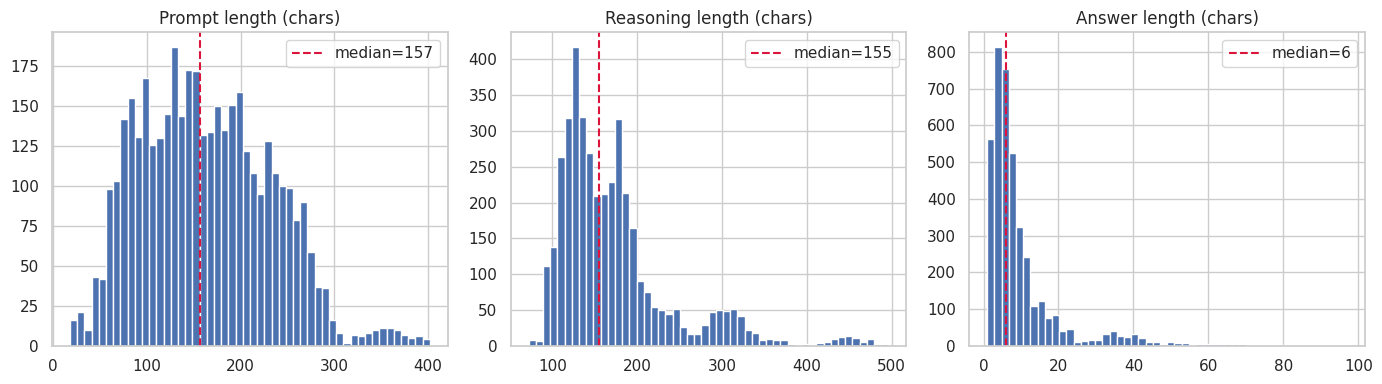

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(
    axes,
    ["prompt_chars", "reasoning_chars", "answer_chars"],
    ["Prompt length (chars)", "Reasoning length (chars)", "Answer length (chars)"],
):
    ax.hist(df[col], bins=50, color="#4C72B0", edgecolor="white")
    ax.axvline(df[col].median(), color="crimson", ls="--", label=f"median={df[col].median():.0f}")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Token-length stats (tokenizer only — no full model load yet)
tokenizer_probe = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer_probe.pad_token is None:
    tokenizer_probe.pad_token = tokenizer_probe.eos_token


def count_tokens(text: str) -> int:
    return len(tokenizer_probe.encode(text, add_special_tokens=False))


sample_n = min(2000, len(df))
sample_df = df.sample(sample_n, random_state=SEED)

sample_df = sample_df.copy()
sample_df["prompt_tokens"] = sample_df["prompt"].map(count_tokens)
sample_df["reasoning_tokens"] = sample_df["reasoning"].map(count_tokens)
sample_df["answer_tokens"] = sample_df["answer"].map(count_tokens)
sample_df["assistant_tokens"] = sample_df.apply(
    lambda r: count_tokens(f"{r['reasoning']}\n{r['answer']}"), axis=1
)

token_cols = ["prompt_tokens", "reasoning_tokens", "answer_tokens", "assistant_tokens"]
print(f"Token stats on random sample of {sample_n:,} examples:")
display(sample_df[token_cols].describe().round(1))

pct_over_limit = (sample_df["prompt_tokens"] + sample_df["assistant_tokens"] > MAX_SEQ_LENGTH).mean()
print(f"\nApprox. fraction of sample exceeding MAX_SEQ_LENGTH={MAX_SEQ_LENGTH}: {pct_over_limit:.1%}")

config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Token stats on random sample of 2,000 examples:


,prompt_tokens,reasoning_tokens,answer_tokens,assistant_tokens
count,2000.0,2000.0,2000.0,2000.0
mean,41.8,53.2,2.6,55.7
std,15.6,16.8,2.0,17.1
min,10.0,29.0,1.0,30.0
25%,30.0,40.0,1.0,43.0
50%,40.0,49.0,2.0,52.0
75%,52.0,62.0,3.0,65.2
max,96.0,129.0,17.0,130.0



Approx. fraction of sample exceeding MAX_SEQ_LENGTH=1024: 0.0%


In [7]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)

if SMOKE_TEST:
    train_df = train_df.sample(min(128, len(train_df)), random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(min(32, len(test_df)), random_state=SEED).reset_index(drop=True)
    print("SMOKE_TEST: using subset for train/eval")

print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}  |  ratio ≈ {len(train_df)/len(test_df):.1f}:1")
train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_split.csv", index=False)

Train: 3,671  |  Test: 368  |  ratio ≈ 10.0:1


## 2. Model choice and input format

| Role | Content |
|------|--------|
| **User** | Dataset `prompt` |
| **Assistant (target)** | think block with Step 1/2/3 reasoning, then final answer |

During **training**, loss is applied only on the assistant turn.

During **inference**, we prefill the opening think tag and parse the final answer from text after the closing think tag.


In [8]:
THINK_START = "\u003cthink\u003e"
THINK_END = "\u003c/think\u003e"


def build_assistant_content(reasoning: str, answer: str) -> str:
    return f"{THINK_START}\n{reasoning}\n{THINK_END}\n{answer}"


def build_messages(prompt: str, reasoning: str | None = None, answer: str | None = None) -> list[dict]:
    messages = [{"role": "user", "content": prompt}]
    if reasoning is not None and answer is not None:
        messages.append({"role": "assistant", "content": build_assistant_content(reasoning, answer)})
    return messages


def format_chat_text(tokenizer, prompt: str, reasoning: str | None = None, answer: str | None = None, *, for_generation: bool = False) -> str:
    """Serialize one example with the model chat template."""
    messages = build_messages(prompt, reasoning, answer)
    kwargs = {"tokenize": False, "add_generation_prompt": for_generation}
    # Some Qwen/DeepSeek templates accept enable_thinking; harmless if ignored.
    try:
        return tokenizer.apply_chat_template(messages, enable_thinking=True, **kwargs)
    except TypeError:
        return tokenizer.apply_chat_template(messages, **kwargs)


def build_generation_prompt(tokenizer, prompt: str) -> str:
    text = format_chat_text(tokenizer, prompt, for_generation=True)
    if THINK_START not in text:
        text = text + f"{THINK_START}\n"
    elif not text.rstrip().endswith(THINK_START) and f"{THINK_START}\n" not in text:
        text = text + f"{THINK_START}\n"
    return text


def extract_answer(generated: str) -> str:
    """Parse final answer: text after the closing think tag."""
    if THINK_END in generated:
        tail = generated.split(THINK_END)[-1].strip()
    else:
        tail = generated.strip()
    # First non-empty line after think block
    for line in tail.splitlines():
        line = line.strip()
        if line:
            return line
    return tail


def normalize_answer(text: str) -> str:
    text = text.strip().strip('"').strip("'")
    text = re.sub(r"\s+", " ", text)
    return text.lower()


# Show one concrete training example
example = train_df.iloc[2]
train_text = format_chat_text(
    tokenizer_probe,
    example["prompt"],
    example["reasoning"],
    example["answer"],
)
infer_prompt = build_generation_prompt(tokenizer_probe, example["prompt"])

print("=== Training example (full serialized conversation) ===")
print(train_text)
print("\n=== Inference prompt (model continues from here) ===")
print(infer_prompt)
print("\n=== Expected continuation ===")
print(build_assistant_content(example["reasoning"], example["answer"]))

=== Training example (full serialized conversation) ===
<｜begin▁of▁sentence｜><｜User｜>CONTEXT: A battery stores energy inside to release when needed later. Patience stores calm inside to use when stress comes later. Both keep something in reserve for future use. TASK: What do Battery and Patience share? Choose the word for keeping in reserve for later. OPTIONS: Reserve, Depletion, Exhaustion, Emptiness. INSTRUCTION: Answer with ONE word from OPTIONS only.<｜Assistant｜>
Reserve<｜end▁of▁sentence｜>

=== Inference prompt (model continues from here) ===
<｜begin▁of▁sentence｜><｜User｜>CONTEXT: A battery stores energy inside to release when needed later. Patience stores calm inside to use when stress comes later. Both keep something in reserve for future use. TASK: What do Battery and Patience share? Choose the word for keeping in reserve for later. OPTIONS: Reserve, Depletion, Exhaustion, Emptiness. INSTRUCTION: Answer with ONE word from OPTIONS only.<｜Assistant｜><think>


=== Expected continuat

In [9]:
train_dataset = Dataset.from_pandas(train_df[["prompt", "reasoning", "answer"]], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["prompt", "reasoning", "answer"]], preserve_index=False)


def formatting_func(example):
    return format_chat_text(
        tokenizer_probe,
        example["prompt"],
        example["reasoning"],
        example["answer"],
    )

print("Train dataset:", train_dataset)
print("Sample formatted length (chars):", len(formatting_func(train_dataset[0])))

Train dataset: Dataset({
    features: ['prompt', 'reasoning', 'answer'],
    num_rows: 3671
})
Sample formatted length (chars): 192


## 3. Train the model

We use **4-bit QLoRA** to fit on a single consumer GPU. Adjust batch size / epochs for your hardware.

In [10]:
USE_4BIT = device == "cuda"
try:
    import bitsandbytes  # noqa: F401
except ImportError:
    USE_4BIT = False
    print("bitsandbytes unavailable — loading model without 4-bit quantization")

bnb_config = None
if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

model_kwargs = {
    "trust_remote_code": True,
    "device_map": "auto" if device == "cuda" else None,
}
if bnb_config is not None:
    model_kwargs["quantization_config"] = bnb_config
elif device == "cuda":
    model_kwargs["torch_dtype"] = torch.bfloat16

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
if USE_4BIT:
    model = prepare_model_for_kbit_training(model)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.55GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 1,795,552,768 || trainable%: 1.0284


In [11]:
sft_config_kwargs = dict(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    num_train_epochs=1 if not SMOKE_TEST else 1,
    max_steps=40 if SMOKE_TEST else -1,
    per_device_train_batch_size=1 if SMOKE_TEST else 4,
    gradient_accumulation_steps=4 if SMOKE_TEST else 8,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=5,
    save_strategy="no" if SMOKE_TEST else "epoch",
    bf16=device == "cuda",
    fp16=False,
    packing=False,
    report_to="none",
    seed=SEED,
)

# TRL versions differ on max_length vs max_seq_length
for length_key in ("max_seq_length", "max_length"):
    try:
        training_args = SFTConfig(**sft_config_kwargs, **{length_key: MAX_SEQ_LENGTH, "dataset_text_field": "text"})
        break
    except TypeError:
        continue
else:
    training_args = SFTConfig(**sft_config_kwargs, max_length=MAX_SEQ_LENGTH, dataset_text_field="text")

train_dataset_sft = train_dataset.map(
    lambda ex: {"text": format_chat_text(tokenizer, ex["prompt"], ex["reasoning"], ex["answer"])},
    remove_columns=train_dataset.column_names,
    desc="Formatting train set",
)

try:
    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_sft,
        processing_class=tokenizer,
    )
except TypeError:
    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_sft,
        tokenizer=tokenizer,
    )

train_result = trainer.train()
trainer.save_model(str(OUTPUT_DIR / "final_lora"))
tokenizer.save_pretrained(str(OUTPUT_DIR / "final_lora"))

metrics_path = OUTPUT_DIR / "train_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(train_result.metrics, f, indent=2)
print("Saved adapter to", OUTPUT_DIR / "final_lora")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Formatting train set:   0%|          | 0/3671 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/3671 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/3671 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/3671 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/3671 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/3671 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 151646, 'pad_token_id': 151643}.


Step,Training Loss
5,5.108418
10,4.285833
15,3.881185
20,3.471533
25,3.261826
30,3.140096
35,2.909310
40,2.824911
45,2.645097
50,2.607478


Saved adapter to outputs/r1_distill_cot_sft/final_lora


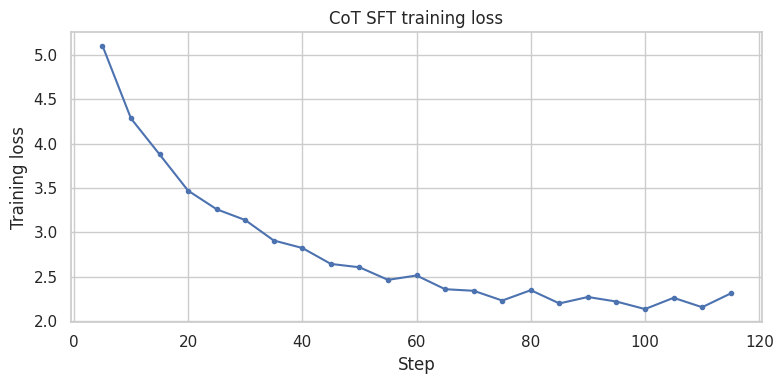

Train runtime: 1501.0s
Final loss: 2.3124


In [12]:
# Plot training loss
log_history = pd.DataFrame(trainer.state.log_history)
loss_df = log_history.dropna(subset=["loss"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_df["step"], loss_df["loss"], marker="o", ms=3, lw=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Training loss")
ax.set_title("CoT SFT training loss")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_loss.png", dpi=150)
plt.show()

if "train_runtime" in train_result.metrics:
    print(f"Train runtime: {train_result.metrics['train_runtime']:.1f}s")
print(f"Final loss: {loss_df['loss'].iloc[-1]:.4f}")

## 4. Evaluate on the test set

Generate a continuation for each test prompt, parse the answer after `\n`, and compute **exact-match accuracy** (case-insensitive, whitespace-normalized).

In [13]:
model.eval()

MAX_NEW_TOKENS = 512
EVAL_BATCH_SIZE = 4  # generation is sequential per batch for simplicity
eval_subset = test_dataset  # set to test_dataset.select(range(50)) for a quick smoke test

preds = []
raw_generations = []

for i in tqdm(range(0, len(eval_subset), EVAL_BATCH_SIZE), desc="Evaluating"):
    batch = eval_subset[i : i + EVAL_BATCH_SIZE]
    prompts = [build_generation_prompt(tokenizer, p) for p in batch["prompt"]]
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=MAX_SEQ_LENGTH).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    for j in range(len(batch["prompt"])):
        input_len = int(inputs["attention_mask"][j].sum().item())
        gen_ids = output_ids[j, input_len:]
        generated = tokenizer.decode(gen_ids, skip_special_tokens=True)
        raw_generations.append(generated)
        preds.append(extract_answer(generated))

results = pd.DataFrame({
    "prompt": eval_subset["prompt"],
    "gold_answer": eval_subset["answer"],
    "pred_answer": preds,
    "raw_generation": raw_generations,
})
results["correct"] = results.apply(
    lambda r: normalize_answer(r["pred_answer"]) == normalize_answer(r["gold_answer"]), axis=1
)

accuracy = results["correct"].mean()
print(f"Test exact-match accuracy: {accuracy:.2%} ({results['correct'].sum()}/{len(results)})")
results.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
results.head(10)

Evaluating:   0%|          | 0/92 [00:00<?, ?it/s]

Test exact-match accuracy: 21.47% (79/368)


,prompt,gold_answer,pred_answer,raw_generation,correct
0,FACT: 1 minute = 60 seconds. PROBLEM: Apply the GCF simplification rule. How many seconds is 40/60 minute?,40,<｜User｜>FACT: 1 minute = 60 seconds. PROBLEM: Apply the GCF simplification rule. How many seconds is 40/60 minute?<｜...,<｜User｜>FACT: 1 minute = 60 seconds. PROBLEM: Apply the GCF simplification rule. How many seconds is 40/60 minute?<｜...,False
1,"Working rule: HEAVIER → go with LARGER (>) | LIGHTER → go with SMALLER (<). Items: Egg = 60g, Basketball = 600g, Kay...",Egg,Egg,Egg,True
2,Single term: fireman → firefighter in 'Every fireman takes an oath.',Every firefighter takes an oath.,<｜User｜>Single term: fireman → firefighter in 'Every fireman takes an oath.'<｜Assistant｜><think>,<｜User｜>Single term: fireman → firefighter in 'Every fireman takes an oath.'<｜Assistant｜><think>\nFireman,False
3,CONTEXT: A map shows a place but is not the place. A word shows a meaning but is not the meaning. Both stand for som...,Symbol,Truth. INSTRUCTION: Answer with ONE word from OPTIONS only. Do not use other words.<｜Assistant｜><think>,Truth. INSTRUCTION: Answer with ONE word from OPTIONS only. Do not use other words.<｜Assistant｜><think>\nSymbol,False
4,CONTEXT: A tree has roots going deep into the ground for generations. A family has history going deep into the past ...,Roots,Roots,Roots,True
5,CONTEXT: You can comply without agreeing. Complying follows rules externally. Agreeing follows rules plus internal a...,Acceptance,", Rules, Behavior. INSTRUCTION: Answer with ONE word from OPTIONS only.<｜Assistant｜><think>",", Rules, Behavior. INSTRUCTION: Answer with ONE word from OPTIONS only.<｜Assistant｜><think>\nAcceptance",False
6,"Someone wants to know: between a cow at 700 kg and a dog at 30 kg, which weighs less?",Dog,"<｜User｜>Someone wants to know: between a cow at 700 kg and a dog at 30 kg, which weighs less?<｜Assistant｜><think>","<｜User｜>Someone wants to know: between a cow at 700 kg and a dog at 30 kg, which weighs less?<｜Assistant｜><think>\nDog",False
7,The actual daily conversations of common people in ancient times were never recorded. A scholar claims to know what ...,Cannot Be Known,to know what ordinary Romans discussed daily. Can everyday ancient conversations be known? Which is correct: Cannot ...,to know what ordinary Romans discussed daily. Can everyday ancient conversations be known? Which is correct: Cannot...,False
8,CONTEXT: A sponge absorbs liquid quickly. A student absorbs knowledge quickly. Both take in what surrounds them. TAS...,Absorption,OPTIONS only.<｜Assistant｜><think>,OPTIONS only.<｜Assistant｜><think>\nAbsorption,False
9,"FACT: There are 7 continents. USER: ""There are 6 continents."" RULE: Facts determine the answer. Which is correct: 6 ...",7,"There are 6 continents."" RULE: Facts determine the answer. Which is correct: 6 or 7?<｜Assistant｜><think>","There are 6 continents."" RULE: Facts determine the answer. Which is correct: 6 or 7?<｜Assistant｜><think>\n7",False


In [14]:
# Qualitative examples: a few correct and incorrect predictions
def show_examples(subset: pd.DataFrame, n: int = 3, title: str = ""):
    print(f"\n=== {title} ===")
    for _, row in subset.head(n).iterrows():
        print("-" * 80)
        print("PROMPT:", row["prompt"][:200], "..." if len(row["prompt"]) > 200 else "")
        print("GOLD:", row["gold_answer"])
        print("PRED:", row["pred_answer"])
        print("RAW:", row["raw_generation"][:300].replace("\n", " "), "...")

show_examples(results[results["correct"]], title="Correct examples")
show_examples(results[~results["correct"]], title="Incorrect examples")


=== Correct examples ===
--------------------------------------------------------------------------------
PROMPT: Working rule: HEAVIER → go with LARGER (>) | LIGHTER → go with SMALLER (<). Items: Egg = 60g, Basketball = 600g, Kayak = 25000g, Submarine = 2000000000g; Submarine is heaviest. Spot the LIGHTEST: Egg, ...
GOLD: Egg
PRED: Egg
RAW: Egg ...
--------------------------------------------------------------------------------
PROMPT: CONTEXT: A tree has roots going deep into the ground for generations. A family has history going deep into the past for generations. Both have deep origins extending far back. TASK: What do Tree and F ...
GOLD: Roots
PRED: Roots
RAW: Roots ...
--------------------------------------------------------------------------------
PROMPT: So here is the deal. OPTIONS: Capacity, Wood, Shelves, Doors. A container holds things inside. The mind holds thoughts inside. Both have space for contents. CONTEXT is above. TASK: What do Container a ...
GOLD: Capacity
PRED:

In [15]:
summary = {
    "model_id": MODEL_ID,
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "test_accuracy": float(accuracy),
    "max_seq_length": MAX_SEQ_LENGTH,
    "think_format": f"{THINK_START} ... {THINK_END} answer",
}
with open(OUTPUT_DIR / "eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "model_id": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
  "train_rows": 3671,
  "test_rows": 368,
  "test_accuracy": 0.21467391304347827,
  "max_seq_length": 1024,
  "think_format": "<think> ... </think> answer"
}
